In [1]:
import os
import pickle

import ase
import rdkit
import numpy as np

In [2]:
npz_path = "./oa_reactdiff/data/SCAN-9w/train.pkl" # with self-loops after Angstrom correction

train_pkl = pickle.load(open(npz_path, "rb"))

In [3]:
def assemble_xyz(z: list, pos: np.ndarray) -> str:
    """Assembling atomic numbers and positions into xyz format

    Args:
        z (list): chemical elements
        pos (tensor): 3D coordinates

    Returns:
        str: xyz string
    """
    natoms =len(z)
    xyz = f"{natoms}\n\n"
    for _z, _pos in zip(z, pos):
        xyz += f"{_z} " + " ".join([f"{x:.8f}" for x in _pos]) + "\n"
    return xyz

In [4]:
atomic_num2sym = {
    1: 'H',    2: 'He',   3: 'Li',   4: 'Be',   5: 'B',    6: 'C',    7: 'N',    8: 'O',    9: 'F',    10: 'Ne',
    11: 'Na',  12: 'Mg',  13: 'Al',  14: 'Si',  15: 'P',   16: 'S',   17: 'Cl',  18: 'Ar',  19: 'K',   20: 'Ca',
    21: 'Sc',  22: 'Ti',  23: 'V',   24: 'Cr',  25: 'Mn',  26: 'Fe',  27: 'Co',  28: 'Ni',  29: 'Cu',  30: 'Zn',
    31: 'Ga',  32: 'Ge',  33: 'As',  34: 'Se',  35: 'Br',  36: 'Kr',  37: 'Rb',  38: 'Sr',  39: 'Y',   40: 'Zr',
    41: 'Nb',  42: 'Mo',  43: 'Tc',  44: 'Ru',  45: 'Rh',  46: 'Pd',  47: 'Ag',  48: 'Cd',  49: 'In',  50: 'Sn',
    51: 'Sb',  52: 'Te',  53: 'I',   54: 'Xe',  55: 'Cs',  56: 'Ba',  57: 'La',  58: 'Ce',  59: 'Pr',  60: 'Nd',
    61: 'Pm',  62: 'Sm',  63: 'Eu',  64: 'Gd', 65: 'Tb',  66: 'Dy',  67: 'Ho',  68: 'Er',  69: 'Tm',  70: 'Yb',
    71: 'Lu',  72: 'Hf',  73: 'Ta',  74: 'W',   75: 'Re',  76: 'Os',  77: 'Ir',  78: 'Pt',  79: 'Au',  80: 'Hg',
    81: 'Tl',  82: 'Pb',  83: 'Bi',  84: 'Po',  85: 'At',  86: 'Rn',  87: 'Fr',  88: 'Ra',  89: 'Ac',  90: 'Th',
    91: 'Pa',  92: 'U',   93: 'Np',  94: 'Pu',  95: 'Am',  96: 'Cm',  97: 'Bk',  98: 'Cf',  99: 'Es', 100: 'Fm',
    101: 'Md', 102: 'No', 103: 'Lr', 104: 'Rf', 105: 'Db', 106: 'Sg', 107: 'Bh', 108: 'Hs', 109: 'Mt', 110: 'Ds',
    111: 'Rg', 112: 'Cn', 113: 'Nh', 114: 'Fl', 115: 'Mc', 116: 'Lv', 117: 'Ts', 118: 'Og'
}

atomic_sym2num = {v: k for k, v in atomic_num2sym.items()}

In [5]:
i = 7
print(train_pkl["reactant"]["charges"][i])
print(train_pkl["reactant"]["positions"][i])

[6, 8, 1, 1, 6, 8, 6, 1, 1, 1, 6, 1, 1, 1, 8, 1, 11]
[[-0.57601452  1.11410078 -2.48545461]
 [ 1.65352938 -0.62406133 -0.35452748]
 [-0.90856452  1.94789629 -1.85876365]
 [-0.77310533  1.18920779 -3.55696697]
 [ 0.39156267 -0.13009379 -0.51466369]
 [-0.56085352 -1.25254422 -0.04992436]
 [ 0.06549904  0.06173383 -1.96691927]
 [-1.49100989 -1.00363639 -0.2056385 ]
 [ 2.04987481 -0.57861017  0.91234752]
 [ 0.4147634  -0.76466004 -2.59224752]
 [ 0.10042209  1.06269595  0.38679945]
 [ 0.36875321  0.77692429  1.41455432]
 [ 0.72325493  1.91544469  0.07553743]
 [-0.9599948   1.36055389  0.35773096]
 [ 2.11511487 -0.93874457  1.96785133]
 [ 2.47829702 -0.31056253  2.61070321]
 [ 1.00276958 -2.43672022  0.90829798]]


In [6]:
train_pkl["reactant"]["rxn"][i]

'ALD1-TS7'

In [7]:
[atomic_num2sym[z] for z in train_pkl["reactant"]["charges"][i]]

['C',
 'O',
 'H',
 'H',
 'C',
 'O',
 'C',
 'H',
 'H',
 'H',
 'C',
 'H',
 'H',
 'H',
 'O',
 'H',
 'Na']

In [8]:
z = [atomic_num2sym[z] for z in train_pkl["reactant"]["charges"][i]]
pos = train_pkl["reactant"]["positions"][i]
xyz_block = assemble_xyz(z, pos)
print(xyz_block)

17

C -0.57601452 1.11410078 -2.48545461
O 1.65352938 -0.62406133 -0.35452748
H -0.90856452 1.94789629 -1.85876365
H -0.77310533 1.18920779 -3.55696697
C 0.39156267 -0.13009379 -0.51466369
O -0.56085352 -1.25254422 -0.04992436
C 0.06549904 0.06173383 -1.96691927
H -1.49100989 -1.00363639 -0.20563850
H 2.04987481 -0.57861017 0.91234752
H 0.41476340 -0.76466004 -2.59224752
C 0.10042209 1.06269595 0.38679945
H 0.36875321 0.77692429 1.41455432
H 0.72325493 1.91544469 0.07553743
H -0.95999480 1.36055389 0.35773096
O 2.11511487 -0.93874457 1.96785133
H 2.47829702 -0.31056253 2.61070321
Na 1.00276958 -2.43672022 0.90829798



In [9]:
mol_block = rdkit.Chem.MolFromXYZBlock(xyz_block)

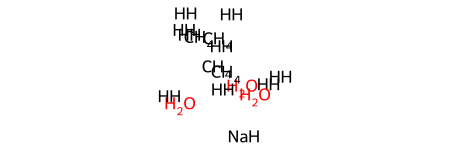

In [10]:
mol_block

In [11]:
from rdkit.Chem.rdDetermineBonds import DetermineConnectivity

In [12]:
from rdkit import Chem

z = [atomic_num2sym[z] for z in train_pkl["reactant"]["charges"][i]]
pos = train_pkl["reactant"]["positions"][i]
xyz_block = assemble_xyz(z, pos)

mol = Chem.MolFromXYZBlock(xyz_block)

#bond_cov_factor = 1.1727 # Based on analyzing Transition1x dataset's fragment labeling.
#DetermineConnectivity(mol,charge=0, covFactor=bond_cov_factor, useVdw=True)
DetermineConnectivity(mol) #,charge=0, covFactor=bond_cov_factor, useVdw=True)


#rdkit.Chem.rdDetermineBonds.DetermineConnectivity(mol_block, covFactor=bond_cov_factor, useVdw=True)
#rdDetermineBonds.DetermineBondOrders(mol_block, charge=0)

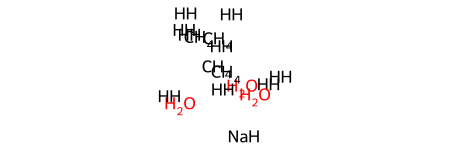

In [13]:
mol_block

In [14]:
for bond in mol.GetBonds():
    print(bond)

In [15]:
def get_rdkit_bonds(mol: rdkit.Chem.Mol):
    bonds = set() # Let's try ordered first.
    for bond in mol.GetBonds():
        i, j = sorted((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))
        bond_tuple = tuple([i, j, str(bond.GetBondType())])
        bonds.add(bond_tuple)
    return bonds

In [16]:
reactant_bonds = get_rdkit_bonds(mol)

In [17]:
reactant_bonds

{(0, 2, 'SINGLE'),
 (0, 3, 'SINGLE'),
 (0, 6, 'SINGLE'),
 (1, 4, 'SINGLE'),
 (1, 16, 'SINGLE'),
 (4, 5, 'SINGLE'),
 (4, 6, 'SINGLE'),
 (4, 10, 'SINGLE'),
 (4, 16, 'SINGLE'),
 (5, 7, 'SINGLE'),
 (5, 16, 'SINGLE'),
 (6, 9, 'SINGLE'),
 (8, 14, 'SINGLE'),
 (10, 11, 'SINGLE'),
 (10, 12, 'SINGLE'),
 (10, 13, 'SINGLE'),
 (14, 15, 'SINGLE'),
 (14, 16, 'SINGLE')}

In [18]:
def count_bond_changes(reactant_bonds: set, product_bonds: set):
    bond_breakages = len(reactant_bonds - product_bonds)
    bond_formations = len(product_bonds - reactant_bonds)
    return bond_breakages, bond_formations

In [19]:
#reactant_mol = mol
#reactant_bonds = bonds

z = [atomic_num2sym[z] for z in train_pkl["product"]["charges"][i]]
pos = train_pkl["product"]["positions"][i]
xyz_block = assemble_xyz(z, pos)

product_mol = Chem.MolFromXYZBlock(xyz_block)

bond_cov_factor = 1.1727 # Based on analyzing Transition1x dataset's fragment labeling.
DetermineConnectivity(product_mol,charge=0, covFactor=bond_cov_factor, useVdw=True)

product_bonds = get_rdkit_bonds(product_mol)

bond_breakages, bond_formations = count_bond_changes(reactant_bonds, product_bonds)

In [20]:
bond_breakages, bond_formations

(4, 1)

In [21]:
reactant_bonds - product_bonds

{(1, 16, 'SINGLE'), (4, 6, 'SINGLE'), (4, 16, 'SINGLE'), (5, 7, 'SINGLE')}

In [22]:
product_bonds - reactant_bonds

{(6, 7, 'SINGLE')}

In [23]:
print(xyz_block)

17

C -0.49780715 0.36296864 -2.01730888
O 1.58004357 0.45934620 0.29936177
H -1.14116386 0.97830500 -2.65390624
H 0.54999522 0.66366350 -1.91101663
C 0.57579966 0.98917316 0.91098509
O -0.12043116 0.37016958 1.78946073
C -0.96478036 -0.69207839 -1.33960973
H -2.01444170 -0.99818592 -1.38728316
H 1.63903876 -0.91536345 0.36141802
H -0.28743884 -1.27014352 -0.70229306
C 0.16361074 2.37078768 0.50061395
H -0.18232128 2.94434386 1.37130989
H 0.98820820 2.87875474 -0.01622539
H -0.68301674 2.26364458 -0.20013876
O 1.46747024 -1.98385109 0.46548943
H 1.76157944 -2.47241355 -0.32130173
Na -0.00295472 -1.73898350 1.98079995



In [24]:
all_atoms = set()
for i in range(len(train_pkl["single_fragment"])):
    z = train_pkl["reactant"]["charges"][i]
    for x in z:
        all_atoms.add(x)

all_atoms

{1, 6, 7, 8, 9, 11, 13, 17, 27}

In [25]:
[atomic_num2sym[z] for z in all_atoms]

['H', 'C', 'N', 'O', 'F', 'Na', 'Al', 'Cl', 'Co']

In [26]:
# ['H', 'C', 'N', 'O', 'F'] = chemically important
# ['Na', 'Al', 'Cl', 'Co'] = catalysts

In [27]:
include_zs = [atomic_sym2num[x] for x in ['H', 'C', 'N', 'O', 'F']]
exclude_zs = [atomic_sym2num[x] for x in ['Na', 'Al', 'Cl', 'Co']]

In [28]:
z = np.array(train_pkl["reactant"]["charges"][7])

In [29]:
z

array([ 6,  8,  1,  1,  6,  8,  6,  1,  1,  1,  6,  1,  1,  1,  8,  1, 11])

In [30]:
include_mask = np.in1d(z, include_zs)
include_mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False])

In [31]:
len(z[include_mask])

16

In [32]:
exclude_rxn_indices = []

for i in range(len(train_pkl["single_fragment"])):
    reactant_z = np.array(train_pkl["reactant"]["charges"][i])
    include_mask = np.in1d(reactant_z, include_zs)
    filtered_z = reactant_z[include_mask]
    reactant_sym = [atomic_num2sym[z] for z in filtered_z]
    reactant_pos = train_pkl["reactant"]["positions"][i][include_mask]
    reactant_xyz_block = assemble_xyz(reactant_sym, reactant_pos)
    reactant_mol = Chem.MolFromXYZBlock(reactant_xyz_block)
    DetermineConnectivity(reactant_mol)

    product_z = np.array(train_pkl["product"]["charges"][i])
    include_mask = np.in1d(product_z, include_zs)
    filtered_z = product_z[include_mask]
    product_sym = [atomic_num2sym[z] for z in filtered_z]
    product_pos = train_pkl["product"]["positions"][i][include_mask]
    product_xyz_block = assemble_xyz(product_sym, product_pos)
    product_mol = Chem.MolFromXYZBlock(product_xyz_block)
    DetermineConnectivity(product_mol)
    
    reactant_bonds = get_rdkit_bonds(reactant_mol)
    product_bonds = get_rdkit_bonds(product_mol)
    bond_breakages, bond_formations = count_bond_changes(reactant_bonds, product_bonds)

    if bond_breakages+bond_formations > 2:
        exclude_rxn_indices.append(i)

In [33]:
%debug

ERROR:root:No traceback has been produced, nothing to debug.


In [34]:
print(product_xyz_block)

17

C -0.45862774 -0.01782102 -1.19438475
C 1.34067517 -1.51656037 0.88644918
N 2.22244370 -0.88696301 0.20261490
N -0.24827868 1.05587603 -0.57435580
H 0.58461077 1.62608159 -0.84174570
H -0.52967835 -1.41955284 1.94342286
C -1.50084189 -1.02429247 -0.82576754
H -1.01637351 -1.96925749 -0.51812009
H -2.17978642 -1.24042064 -1.66811026
H -2.08442899 -0.63183013 0.01576398
C 0.44691773 -0.91074208 1.92633546
H 1.21384241 -2.58964636 0.67752923
H 0.27851312 0.15724602 1.70841571
H 0.89609176 -1.01227425 2.92969197
O 0.36618986 -0.44624545 -2.28385890
H 2.28574709 0.13305504 0.41385791
H -0.02524705 -1.20813090 -2.75235652



In [38]:
len(exclude_rxn_indices)/len(train_pkl["single_fragment"])

0.2187597697555952